#  Performance study: NSR vs. V magnitude

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [398]:
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [209]:
def add_mag_column(cfile, df):
    # Load input catalogue
    dc = pd.read_feather(cfile)
    N = len(dc)
    # Merge the two data frames
    mag  = np.array([])
    ncon = np.array([])
    for i in range(N):
        nobs = len(df[df.star == i+1])
        mags = dc.mag.iloc[i] * np.ones(nobs)
        mag  = np.concatenate((mag, mags))
        ncons = dc.ncon.iloc[i] * np.ones(nobs)
        ncon  = np.concatenate((ncon, ncons))   
    df["mag"]  = mag
    df["ncon"] = ncon
    # Correct columns of magnitudes
    df['mag'] = mag[:len(df)]
    return df

## Download data from FTP

In [190]:
# User parameters
idir = "/lhome/nicholas/data/platosimPaper/NSR_old"
idir0  = "/lhome/nicholas/data/platosimPaper/NSR_reference"
idir1  = "/lhome/nicholas/data/platosimPaper/NSR_jitter1x"
idir2  = "/lhome/nicholas/data/platosimPaper/NSR_jitter5x"
vfile = idir + "/starcat_all_SPF_CamVis24_NewCat_targets.ftr"

In [367]:
dv = pd.read_feather(vfile)
dv

,level_0,index,ID,ra,dec,mag,sample,Teff,R,M,ncams,field,ncon
0,0,11427,3580591,96.035785,-63.750175,10.618521,8,6198.980437,1.222975,1.170981,12,S,1
1,1,40987,8566638,78.325748,-53.869161,10.768657,8,6014.552333,1.084527,1.085912,12,S,0
2,2,130646,20316719,77.146704,-29.364064,10.060707,1,6327.395651,1.711475,1.353518,12,S,0
3,3,6985,2772685,95.010392,-65.708698,11.282410,8,6120.226541,1.278223,1.174449,12,S,0
4,4,48414,9711075,54.789350,-51.602852,9.783687,1,6453.527690,3.011151,1.700624,12,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2495,11025,3513714,121.597543,-63.907393,9.182682,1,5951.671650,2.759217,1.513884,6,S,0
9996,2496,57298,10831105,120.532198,-49.150404,11.718769,8,6078.725266,1.310902,1.177072,6,S,2
9997,2497,33957,7480934,114.139785,-55.993081,12.070425,8,6063.742860,1.490549,1.230798,6,S,1
9998,2498,146694,22872949,102.482683,-24.950299,10.369341,8,5753.555180,1.217956,1.082843,6,S,1


## Test examples

### NSR for a single star

In [391]:
# Load light curve object for the first star only and unpack the data
lcs = LightCurve(f"{idir1}/000000001", mode="multi")
lcs.unpack()

In [392]:
# Fetch all files
filenames = lcs.files("hdf5")
filenames

['/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_jitter1x/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimP

In [396]:
lc = LightCurve(filenames[0])
lc.data()

,time,flux,flux_input
0,12.5,225849.364868,425342.0
1,37.5,225144.217651,425342.0
2,62.5,226073.190796,425342.0
3,87.5,225983.375122,425342.0
4,112.5,224789.900269,425342.0
...,...,...,...
3451,86287.5,225696.404175,425342.0
3452,86312.5,225321.731567,425342.0
3453,86337.5,224968.817261,425342.0
3454,86362.5,225167.370483,425342.0


In [410]:
f = SimFile(filenames[0])
mask = f.getApertureMask(1)
nsr = mask[-1][0]
mask

(array([[4, 4, 3, 3, 4, 5, 4, 5, 3, 3, 5]], dtype=uint32),
 array([[4, 3, 4, 3, 5, 4, 2, 3, 2, 5, 2]], dtype=uint32),
 array([0], dtype=uint32),
 array([11], dtype=uint32),
 array([0.00117357]))

In [186]:
# lc.data()
lc, ncam, flag = lcs.merge_test(quarter=1, flux_group_mean=True, suffix='hdf5')
df = lc.data()
df.flux += df.flux.mean()


df["time"] = df.time/86400.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                       
# Bin to devide data                                                                                                                                                                                
dt = 1/24.                                                                                                                                                                                          
nbins = round( (df["time"].max() - df["time"].min()) / dt) + 1                                                                                                                                      
tbins = np.linspace(df["time"].min(), df["time"].max(), nbins)
nbin  = len(df[df["time"].between(tbins[0], tbins[1])])                                                                                                                                             
# Bin data                                                                                                                                                                                          
flux_dex = df.columns.get_loc('flux')                                                                                                                                                               
data  = [df[df["time"].between(tbins[i], tbins[i+1])].to_numpy() for i in range(nbins-1)]                                                                                                           
sigma = np.array([data[i][:,flux_dex].std() for i in range(len(data))])                                                                                                                             
                                                                                                                                                                                                            
# Return NSR                                                                                                                                                                                        
NSR = np.mean(sigma) * 1e6 / np.sqrt(nbin) 
NSR

70.45150857699063

In [ ]:
# Show plot to verify result
lc.plot(time_unit="h", flux_unit='ppm', ncam=ncam, quarter=1, binsize=1, alpha=0.5, figsize=(9,5));

### Test merged N-CAM

In [200]:
ofile = idir + "/results_per_star_test.ftr"

In [198]:
lcs = LightCurve(idir, mode="multi")
lcs.run_NSRvsMag_analysis_perStar_test(ofile, vfile, 10, suffix="hdf5")

100%|██████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.


In [199]:
# Load results and sort logically
df = pd.read_feather(ofile)
df

,index,star,quarter,ncam,NSR,mag
0,0,1,1,12,529.540283,10.768657
1,0,2,1,18,265.366913,10.060707
2,0,3,1,12,21.704897,11.282411
3,0,4,1,12,417.706238,9.783688
4,0,5,1,6,26.837667,12.412833
5,0,6,1,12,949.689087,12.663273
6,0,7,1,6,128.574677,9.881067
7,0,8,1,12,42.187199,12.141473
8,0,9,1,12,64.731613,11.285676
9,0,10,1,6,58.505772,9.573740


## Analysis of Merged N-CAM LCs

### Old simulations with nominal jitter

In [216]:
idir  = "/lhome/nicholas/data/platosimPaper/NSR_old" 
ofile = idir + "/results_per_star_old.ftr"

In [217]:
lcs = LightCurve(idir, mode="multi")
lcs.run_NSRvsMag_analysis_perStar(ofile, 1000, suffix="hdf5")

100%|██████████████████████████████████████████████████| 1000/1000 [01:08<00:00,


In [218]:
# Load results and sort logically
df = add_mag_column(vfile, pd.read_feather(ofile))
df

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.916477,0,10.618521,1.0
1,0,2,1,18,50.737873,0,10.768657,0.0
2,0,3,1,12,41.747032,0,10.060707,0.0
3,0,4,1,12,80.457657,0,11.282410,0.0
4,0,5,1,6,50.640957,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
974,0,996,1,12,36.550026,0,9.802819,2.0
975,0,997,1,6,167.500458,0,12.045320,1.0
976,0,998,1,12,167.470718,0,12.592213,0.0
977,0,999,1,12,135.968094,0,12.237439,0.0


In [219]:
# Without contaminants
dc = df.loc[df.ncon == 0]

<IPython.core.display.Javascript object>


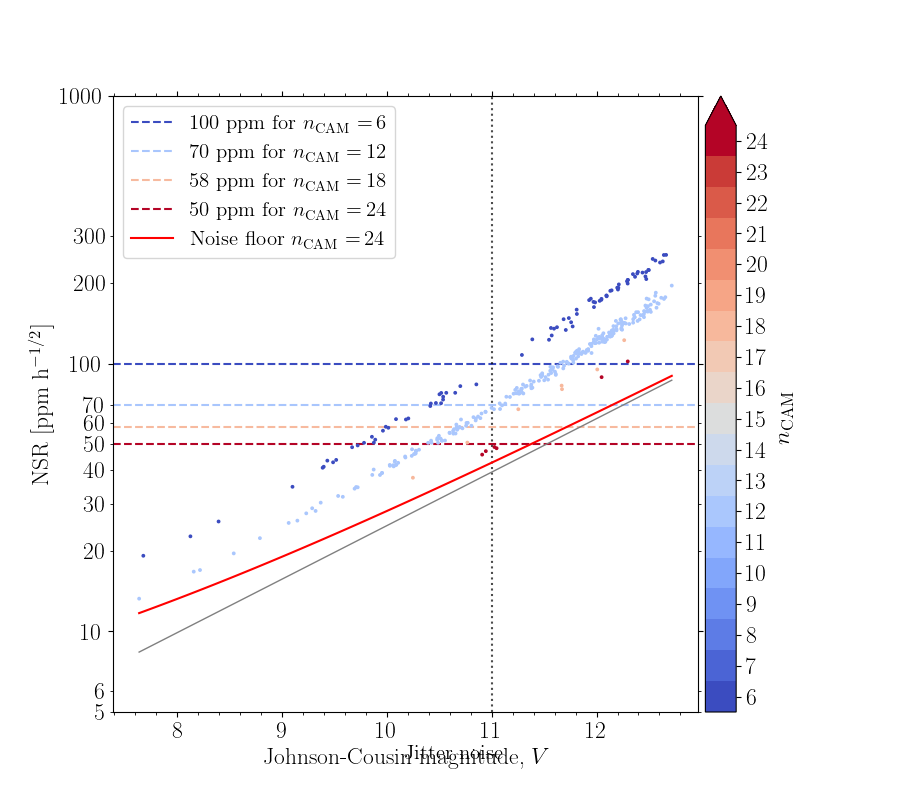

/tmp/ipykernel_8725/3235788916.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [220]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(dc, column="ncam", passband='V', residuals="multi", noise_ncam=24, 
                                legend=True, grid=False, figsize=(9,8))

# Set axes limits
# ax.set_xlim(6, 12.77)
ax.set_ylim(5, 1000) #340)

# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100, 1000]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);

# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

In [11]:
df.loc[(df.NSR <20) & (df.mag > 11)]

,index,star,quarter,ncam,NSR,flag,mag,ncon
6372,0,6446,1,24,10.484730,0,11.801595,1.0
9071,0,9512,1,6,19.826637,0,11.133751,2.0
9201,0,9665,1,6,3.048779,0,11.227474,5.0


### New simulation with jitter x 1 amplitude

In [251]:
idir  = "/lhome/nicholas/data/platosimPaper/NSR_jitter1x" 
ofile = idir + "/results_per_star_jitter1x.ftr"

In [250]:
# lcs = LightCurve(idir, mode="multi")
# lcs.run_NSRvsMag_analysis_perStar(ofile, 10000, suffix="hdf5")

In [252]:
# Load results and sort logically
df1 = add_mag_column(vfile, pd.read_feather(ofile))
# Without contaminants
dc1 = df.loc[df.ncon == 0]

<IPython.core.display.Javascript object>


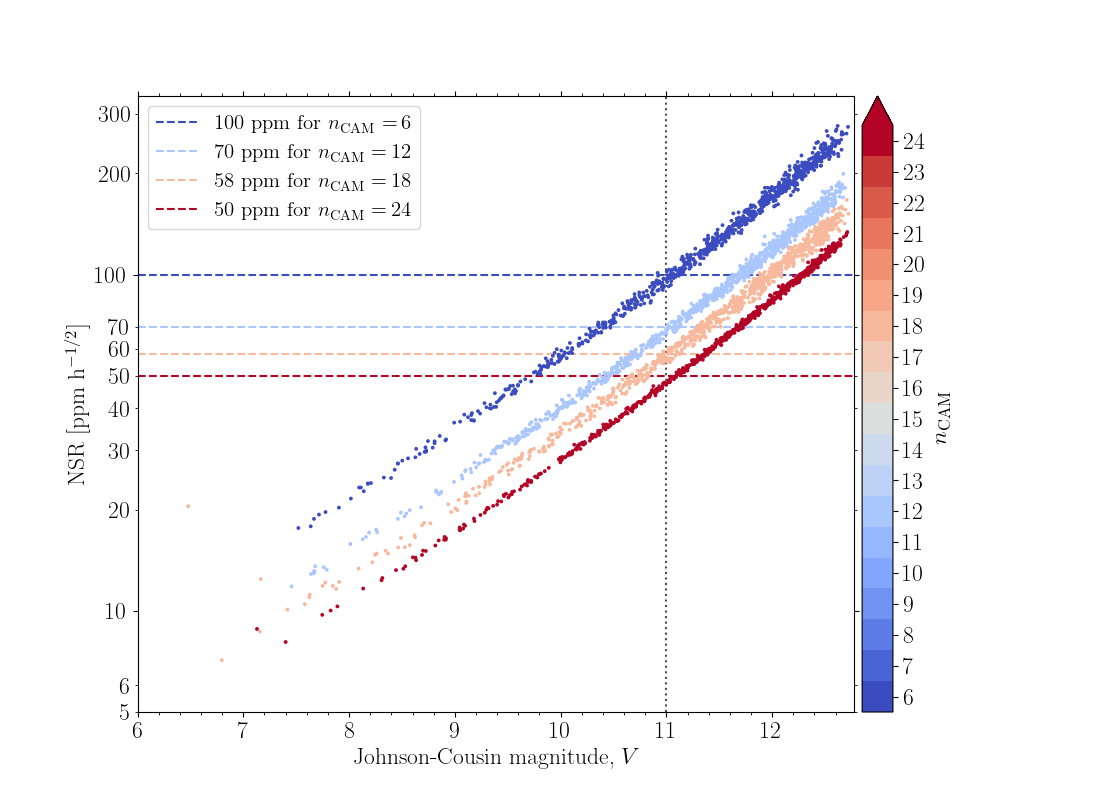

/tmp/ipykernel_8725/2368661528.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [249]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(dc, column="ncam", passband='V', residuals="multi", 
                                noise_ncam=False, legend=True, grid=False, figsize=(11,8))
# Set axes limits
ax.set_xlim(6, 12.77)
ax.set_ylim(5, 340)
# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100, 1000]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);
# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

### New simulation with jitter x 5 amplitude

In [370]:
idir  = "/lhome/nicholas/data/platosimPaper/NSR_jitter5x" 
ofile = idir + "/results_per_star_jitter5x.ftr"

In [246]:
# lcs = LightCurve(idir, mode="multi")
# lcs.run_NSRvsMag_analysis_perStar(ofile, 10000, suffix="hdf5")

In [371]:
# Load results and sort logically
df5 = add_mag_column(vfile, pd.read_feather(ofile))
# Without contaminants
dc5 = df.loc[df.ncon == 0]
df5

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.513428,0,10.618521,1.0
1,0,2,1,6,85.023415,0,10.768657,0.0
2,0,3,1,12,42.123165,0,10.060707,0.0
3,0,4,1,12,78.879196,0,11.282410,0.0
4,0,5,1,6,50.056236,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
9500,0,9995,1,6,216.236176,0,12.194971,1.0
9501,0,9997,1,6,148.673264,0,11.718769,2.0
9502,0,9998,1,6,213.316483,0,12.070425,1.0
9503,0,9999,1,6,72.853424,0,10.369341,1.0


<IPython.core.display.Javascript object>


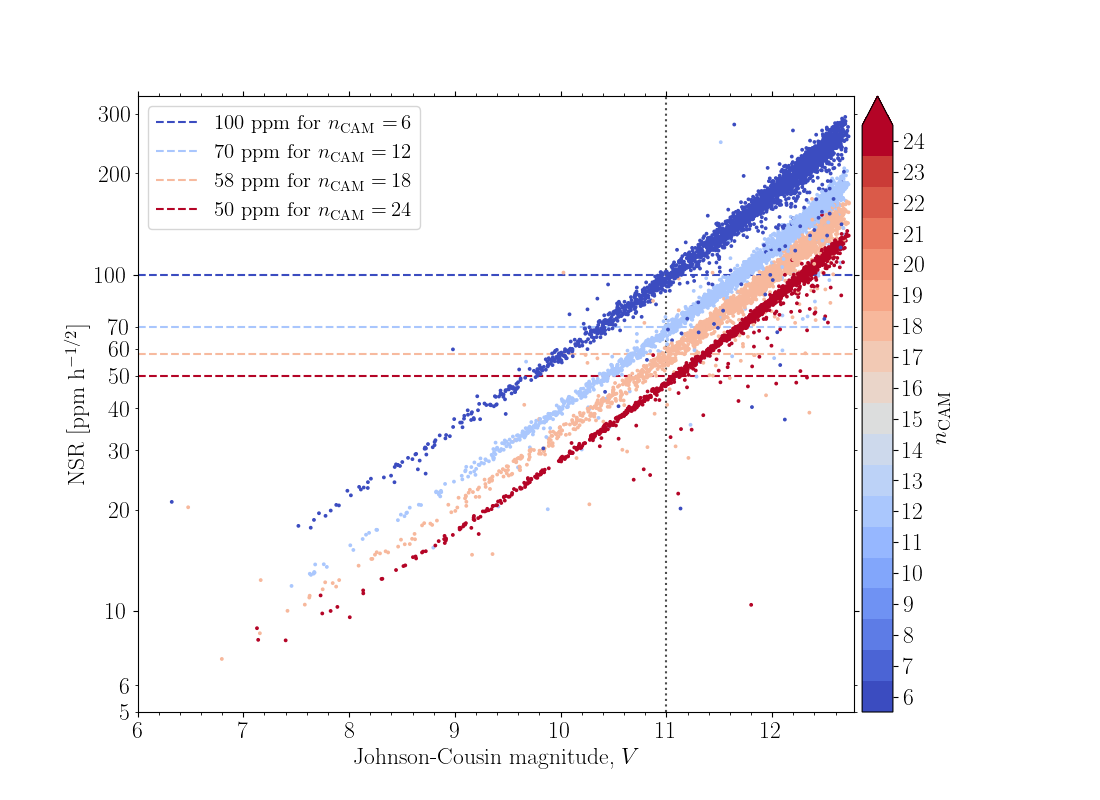

/tmp/ipykernel_8725/4022370221.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [265]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df5, column="ncam", passband='V', residuals="multi", 
                                noise_ncam=False, legend=True, grid=False, figsize=(11,8))
# Set axes limits
ax.set_xlim(6, 12.77)
ax.set_ylim(5, 340)
# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100, 1000]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);
# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

### Residuals

In [260]:
df['res'] = df5.NSR - df1.NSR
df

,index,star,quarter,ncam,NSR,flag,mag,ncon,res
0,0,1,1,12,55.207348,0,10.618521,1.0,0.306080
1,0,2,1,6,84.092682,0,10.768657,0.0,0.930733
2,0,3,1,12,41.621445,0,10.060707,0.0,0.501720
3,0,4,1,12,79.712105,0,11.282410,0.0,-0.832909
4,0,5,1,6,50.696774,0,9.783687,0.0,-0.640537
...,...,...,...,...,...,...,...,...,...
9500,0,9995,1,6,220.031525,0,12.194971,1.0,-3.795349
9501,0,9997,1,6,147.951218,0,11.718769,2.0,0.722046
9502,0,9998,1,6,219.557373,0,12.070425,1.0,-6.240891
9503,0,9999,1,6,72.773529,0,10.369341,1.0,0.079895


<IPython.core.display.Javascript object>


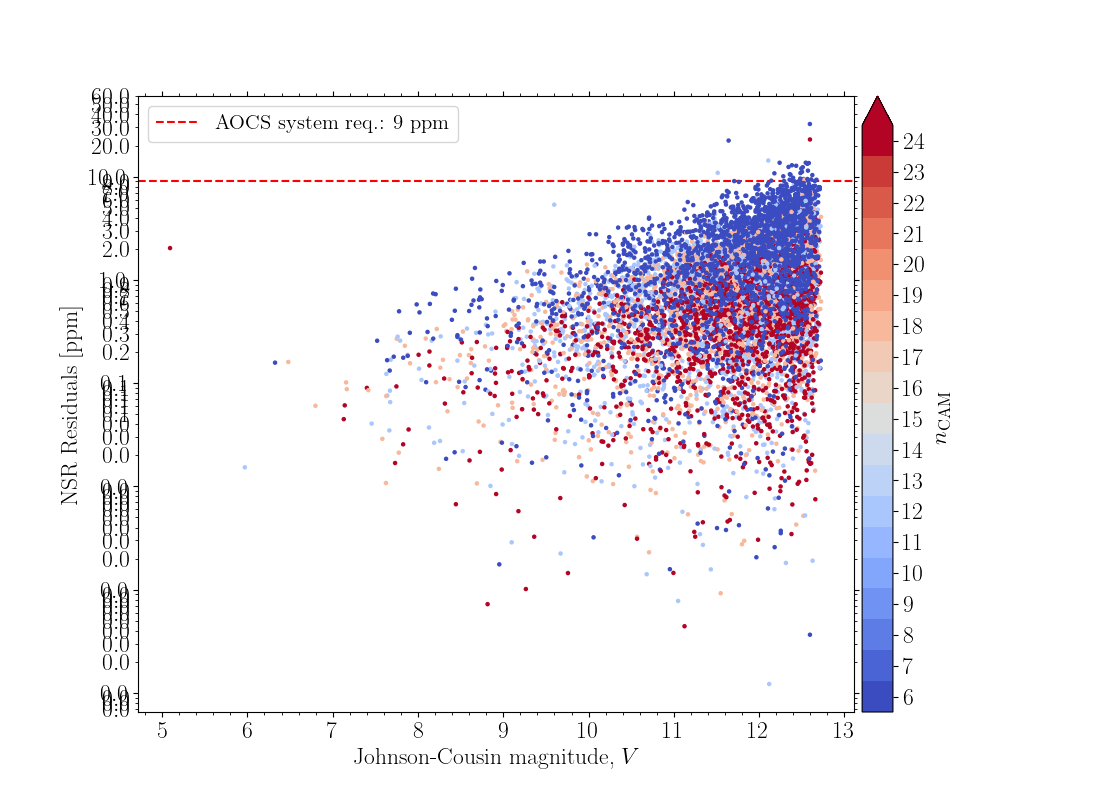

In [262]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", passband='V', residuals='system', 
                                noise_ncam=False, legend=True, grid=False, figsize=(11,8))

## Analysis of merged N-CAM LCs using input signal

In [315]:
idir  = idir1
ofile = idir + "/results_per_star_jitter1x_input.ftr"

In [368]:
# # Find reference signal
# lcs = LightCurve(idir, mode="multi")
# lcs.run_NSRvsMag_analysisPerStar_test(vfile, ofile, 100)

In [322]:
# Load results and sort logically
df = pd.read_feather(ofile)
# Without contaminants
dc = df.loc[df.ncon == 0]

<IPython.core.display.Javascript object>


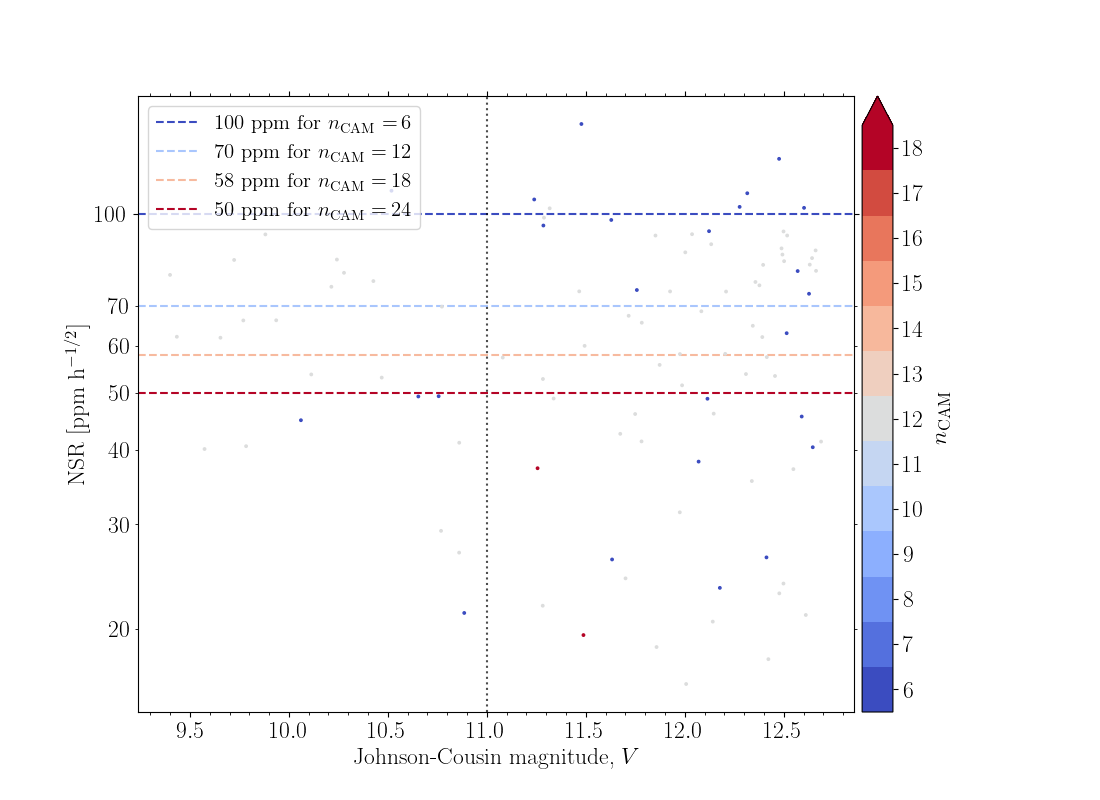

/tmp/ipykernel_8725/1781421076.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [323]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", passband='V', residuals="multi", 
                                noise_ncam=False, legend=True, grid=False, figsize=(11,8))
# Set axes limits
# ax.set_xlim(6, 12.77)
# ax.set_ylim(5, 340)
# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100, 1000]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);
# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

In [307]:
# df = pd.DataFrame()
# for i in range(1, len(df0)):
#     star = df0.loc[df0["star"] == i]
#     ncam = len(star)
#     if ncam > 0:
#         mag  = star.mag.iloc[0]
#         nsr  = star.NSR.mean() / np.sqrt(ncam)
#         data = {'star':i, "mag":mag, "ncam":ncam, "NSR":nsr}
#         df = df.append(data, ignore_index=True)

## Analysis merged N-CAMs using signal reference

In [353]:
ofile = idir1 + "/results_per_star_reference.ftr"

In [388]:
# Find reference signal
lcs = LightCurve(idir1, mode="multi")
lcs.run_NSRvsMag_analysis_perStar_reference(vfile, idir0, idir1, ofile, 100)

100%|██████████████████████████████████████████████████| 100/100 [00:11<00:00,  


In [389]:
# Load results and sort logically
df = pd.read_feather(ofile)
# Without contaminants
dc = df.loc[df.ncon == 0]
df

,index,star,quarter,ncam,ncon,mag,NSR
0,0,1,1,12,1,10.618522,481.979370
1,0,2,1,6,0,10.768657,502.470062
2,0,3,1,12,0,10.060707,364.866913
3,0,4,1,12,0,11.282411,647.395142
4,0,5,1,6,0,9.783688,298.598602
...,...,...,...,...,...,...,...
95,0,96,1,12,2,11.873032,959.918884
96,0,97,1,6,1,12.414405,1406.312622
97,0,98,1,12,2,12.602640,1346.519775
98,0,99,1,12,1,10.242494,394.062714


<IPython.core.display.Javascript object>


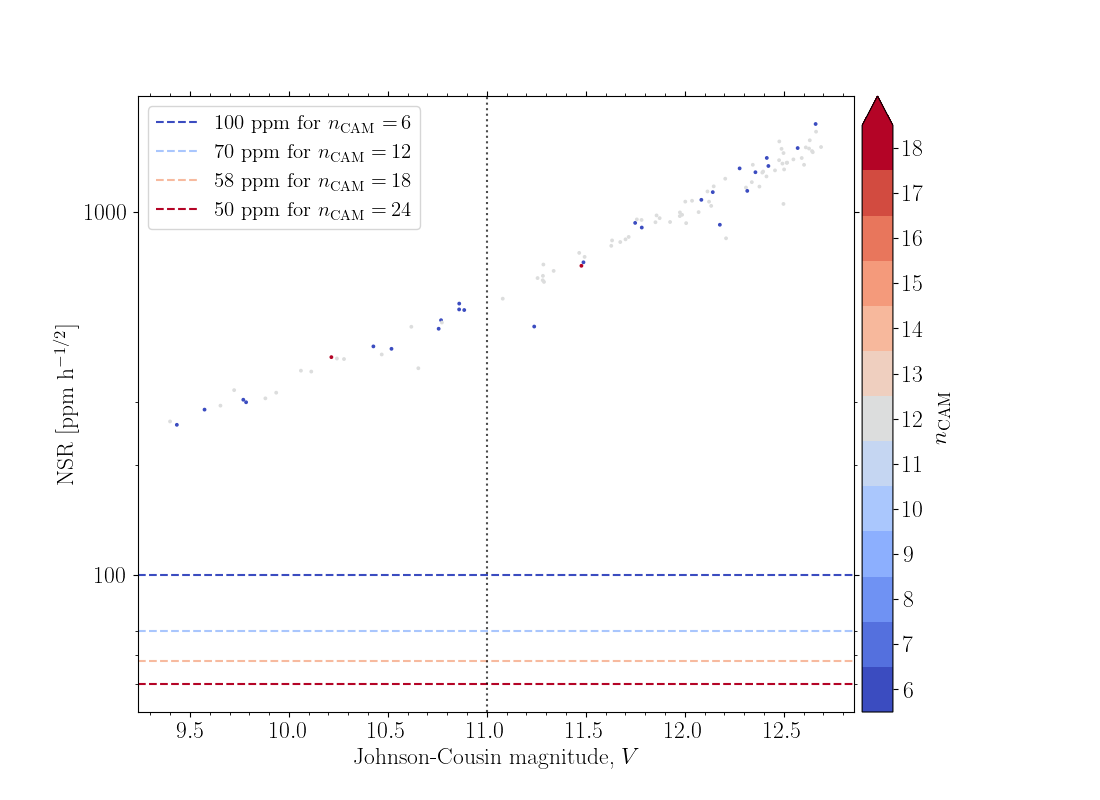

/tmp/ipykernel_8725/1781421076.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [390]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", passband='V', residuals="multi", 
                                noise_ncam=False, legend=True, grid=False, figsize=(11,8))
# Set axes limits
# ax.set_xlim(6, 12.77)
# ax.set_ylim(5, 340)
# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100, 1000]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);
# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);